
## MACHINE LEARNING IN FINANCE
MODULE 2 | LESSON 3


---

# **DIMENSIONALITY REDUCTION: PRINCIPAL COMPONENT ANALYSIS**

|  |  |
|:---|:---|
|**Reading Time** |  30 minutes|
|**Prior Knowledge** | Unsupervised learning, correlation, eigenspaces  |
|**Keywords** |principal components, loadings  |


---

*In the first lesson, we introduced the concept of unsupervised learning, studied clustering algorithms, and examined how they identify structure in a given dataset. In the previous lesson, we applied these concepts using hierarchical clustering. In this lesson, we shift our focus to another topic in unsupervised learning: dimensionality reduction*

## **1. Introduction**

Dimensionality reduction algorithms compress data with many features into one with fewer features, while still retaining the most important information and eliminating information we consider redundant or duplicating. This is done by projecting a high dimensional dataset to a lower dimensional space.

A common misconception in machine learning is that the more features we add to an algorithm, the more accurate the model becomes. This has been disproven. It has been shown that to improve the performance of machine learning algorithms we should consider applying dimensionality reduction to our features so as to only remain with important and optimal features for the machine learning task of interest. Dimensionality reduction helps prevent the *curse of dimensionality* problem, that is to say, machine learning algorithms become inefficient in training data with bigger feature spaces.

The most common techniques in dimensionality reduction are 
1. Feature selection
2. Feature extraction

Dimensionality reduction finds application in
1. Feature engineering
2. Noise reduction or filtering techniques
3. Generating artificial data for machine learning tasks.
4. Financial modeling or risk analysis by combining a huge number of market metrics to fewer components that allow for efficient modeling

Let's discuss the curse of dimensionality in detail.

### **1.1 Curse of Dimensionality**

Machine learning models will often underfit on data with few features and overfit on data with too many features. This is what we refer to as the curse of dimensionality. It blocks many machine learning algorithms from achieving reasonable results as they make optimization of algorithms infeasible.

As dimension of data increases, difficulty in recognizing patterns also increases.

### **1.2 Dimensionality Reduction**

Reducing dimensions of a dataset removes redundant features from the dataset but retains optimal variables that can be applied to predict target variables more accurately.

Dimensionality reduction also reduces the complexity of the model. A critical step in dimensionality reduction is the covariance or correlation matrix, and it helps check the correlation between our variables.

### **1.3 Correlation**

Variables that are highly correlated with one another result in the variables' coefficients being unstable and, when used in regression, perform poorly. In machine learning, we use multicollinearity to find existence of correlation between independent variables.

The presence of multicollinearity is checked using Variance Inflation Factor (VIF) given by
$$\text{VIF} = \frac{1}{1 - R^2}$$

where $R^2 = 1 - \frac{SS_{RES}}{SS_{TOT}} = 1 - \frac{\sum_i (y_i - \hat{y})^2}{\sum_i (y_i - \bar{y})^2}$.

The VIF will always be greater than or equal to 1 and is interpreted as follows:
1. A VIF equal to one implies that the variable is independent of the other variables.
2. A VIF between 1 and 5 means the variables are moderately correlated.
3. A VIF greater than 5 implies that the variables are highly correlated.

Therefore, for a desirable predictive model, we will want the VIF to be as close to one as possible. 

Correlation values range from -1 to +1 and the values are interpreted below:
1. Values close to +1 show a positive correlation.
2. Values close to -1 show a negative correlation.
3. Values close to 0 mean there exists no correlation between the two variables.

We can present the correlation between variables in a heatmap plot as shown below:


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

In [2]:
# Load Iris Dataset
iris = datasets.load_iris()

# Create a Covariance Matrix
cov_data = np.corrcoef(iris.data.T)
cov_data

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

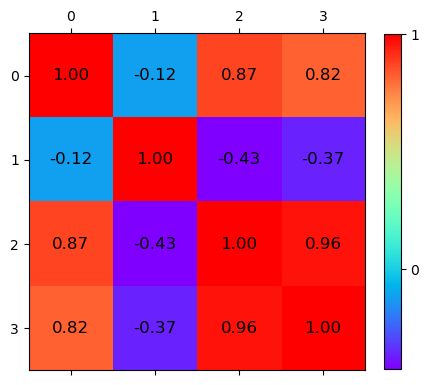

In [3]:
# Plotting the covariance matrix using a heatmap

img = plt.matshow(cov_data, cmap=plt.cm.rainbow)
plt.colorbar(img, ticks=[-1, 0, 1], fraction=0.045)
for x in range(cov_data.shape[0]):
    for y in range(cov_data.shape[1]):
        plt.text(
            x,
            y,
            "%0.2f" % cov_data[x, y],
            size=12,
            color="black",
            ha="center",
            va="center",
        )

plt.show()

From the heatmap above we see that the first and third features, first and fourth features, and third and fourth features are correlated while the second feature can be considered independent from the other features.

Therefore, of the three highly correlated features, we can keep one and drop the other two, which in this case we consider duplication of information.

As mentioned earlier, we can use the following techniques for dimensionality reduction.
- Feature selection
- Feature extraction

#### **Feature Selection**
In this technique, we select a subset of the original variables, that is, choose variables that better represent other variables.

We can employ feature selection in one of the following instances:
- When the features are non-numeric
- When we need to extract important features
- To retain the measurements as they were originally without transformation.

We can observe feature selection using the following vector equation
$$\vec{x} = \pmatrix{x_1\\ x_2\\ \vdots \\ \vdots\\ x_N} → \pmatrix{x_{i1}\\ x_{i2}\\ \vdots \\ x_{ik}}$$
where $k<< N$

Feature selection, however, requires a search strategy to choose the best features, and this may pose a challenge to an unsupervised learning model. Absence of class information makes it difficult to measure which features will improve the performance of a machine learning model. Common feature selection techniques without class information are done by selecting variables with higher variances.

#### **Feature Extraction**

In this method, we transform raw features to new features by mapping from the original features
$$\vec{x} = \pmatrix{x_1\\ x_2\\ \vdots \\ \vdots\\ x_N} \xrightarrow{f(\vec{x})} \pmatrix{y_1\\ y_2\\ \vdots \\ y_k}$$
where $k<< N$.

The transformation can be linear or non-linear.

The linear feature extraction techniques are listed below:
1. Principal Component Analysis (PCA)
2. Linear Discriminant Analysis (LDA)

In this lesson, we will focus on PCA.

## **2. Principal Component Analysis (PCA)**

PCA is a useful technique to reduce dimensionality of our feature set while retaining information from the original features. 
It does this through feature extraction, that is, new features are formed by performing a linear combination of the original features. 
By applying PCA to a dataset, we are able to learn different representations of the data explaining the original data points.

The linear transformation of the features can be represented by the equation $$y = WX$$ where $W$ are the weights, $X$ the original features and $y$, the principal components.

The linear transform poses challenge in that it makes the transformed features less interpretable and therefore not useful for follow-up analysis.

The principal components, $y_i$, explains a higher percent of the original data's variability and the weights $W_{ij}$ show the contribution of our original features to the resulting principal components.

Consider an example with two variables; $$y_i = w_{i,1} x_1 + w_{i2} x_2$$

We refer to the weights $(w_{i,1}, w_{i,2})$ as the component **loadings**. The first principal component, $y_1$, explains most of the variation in our dataset, $y_2$ which is orthogonal to $y_1$ explains most of the remaining variations. If we had more features, then the additional principal components would be orthogonal to each other as well.

The new variables we find can be linearly combined to get back our original data features. These new variables are referred to as the principal components (PCs) and the PCs are orthogonal (independent) of each other.

Principal component analysis can be used in the following ways:
1. Visualizing a high dimensional dataset into lower dimensional plots.
2. Removing noise from a data.
3. Finding structure in a dataset.
4. Reduce overfitting in a data.

Mathematically we can generalize the objectives of PCA as:
- To find an orthonormal basis for a dataset.
- Arrange dimensions sequentially in the order of their importance.
- Remove dimensions with lower significance.
- Ensure the new variables are uncorrelated. 

### **2.1 Computing the Principal Components and Loadings**

Calculating the principal components involves the use of a correlation matrix of the data or a covariance matrix, and it only works on numerical features. These are the steps to performing dimensionality reduction.

1. Standardization: The first step in a PCA process is to standardize the dataset. This is necessary because PCA is sensitive to datasets whose features have different value ranges or have outliers. This step would therefore ensure that each feature contributes equally. Standardization is achieved by substracting from a feature its mean and dividing by its standard deviation. The standardized feature would therefore have a mean of zero and standard deviation of one (unit length of one).

2. Centering data around the origin: We proceed by calculating the average of each feature and find the center of the data. We shift the data so that our center is at the origin without altering the distance between the data points.

3. The first principal component (PC1) is computed by finding a linear combination of the features that maximizes the total variation in the data
$$Y_1 = a_{11} X_1 + a_{12} X_2 + \cdots + a_{1N} X_N$$ The implication of this is that we can increase the variance of $Y_1$ to be as large as possible. To prevent such an occurrence, the sum of squares of the weights is equal to 1, that is, 
$$a_{11}^2 + a_{12}^2 +\cdots a_{1N}^2 = 1$$

4. We repeat this process by finding the principal component (PC2) that passes through the origin and is orthogonal (i.e., uncorrelated) to PC1 and accounts for the next high variance.
$$Y_2 = a_{21} X_1 + a_{22} X_2 + \cdots + a_{2N} X_N$$
5. This process continues until we have as many principal components as the original features. Once we have all the principal components, then the total variance of the principal components will equal the total variance of the original features, and with this, we are certain that no information has been lost in the transformation process. As seen in the steps above, the PCA rotates data samples in the direction of the axes, then shifts the data so that their mean equals 0 but most importantly ensuring that no information is lost in the process.

In matrix form, finding PCA can be written as $$Y= XA$$

The rows of the matrix $A$ are the eigenvectors and they specify how the principal components are oriented compared to the original features. The composition of the eigenvectors are the weights $a_{ij}$ and are referred to as the loadings. Loadings tell us how each feature contributes to a principal component.

Loadings range from $-1$ to $1$ and large loadings (close to $1$ or $-1$) indicate the presence of a strong relationship between a particular feature and the principal component while loadings closer to zero indicate a weaker relationship. The sign of the loading shows whether a feature is positively or negatively correlated to the principal component.

Given a matrix $A$ and the variance-covariance matrix of our original data, $S_X$, then the variance-covariance matrix of the resulting principal components will be $$S_Y = A S_X A^T$$

$S_Y$ is a diagonal matrix whose values are the eigenvalues (or the explained variance) by the corresponding principal components. The PCA performs dimensional reduction by projecting data onto the principal component space and then orders the sequence of PCs in the direction of the largest variance in our dataset. This ensures that the PCs are not correlated with each other and they form a set of orthogonal basis.
Therefore the eigenvalues are arranged such that they decrease monotonically from the largest to the smallest. We use **scree plot** to visualize the rate at which the explained variance is decreasing as we add more principal components. 

An ideal scree plot would steadily bend and resemble an elbow plot, where insignificant PCs will flatten out and we get a nice cut-off allowing us to pick the number of optimal PCs easily. In case the scree plot is not so ideal, we can use the rules below to choose the PCs.
1. Apply the Kaiser rule, that is, the PCs should have an eigenvalue of at least 1.
2. The selected PCs should contribute at least $80\%$ of the variance.

In case we get more than 3 PCs, we should consider using other dimensional reduction techniques as the PCA would not be the best way to visualize our data. In the new coordinate system, the position of the principal components are called the scores.

Below is a recap of the eigenspaces that we have learned above.

### **2.2 Mathematics behind PCA**

Below we review the concept of eigenspaces;

Let **A** be an $n×n$ matrix. The eigenvalues of **A**  are the solution to the characteristic equation
$$\text{determinant}(\textbf{A} - λ \textbf{I}) = |(\textbf{A} - λ \textbf{I})| = 0$$
where $\textbf{I}$ is an $n× n$ identity matrix.

If $λ$ is an eigenvalue of $\textbf{A}$, then there exists a vector $\vec{x}$ such that
$$\textbf{A} \vec{x} = λ \vec{x}$$

This vector $\vec{x}$ is referred to as the eigenvector of the matrix $\textbf{A}$ associated with the eigenvalue $λ$ and it is not unique.

Consider a $2×2$ matrix $\textbf{A}$ with eigenvectors $\vec{x_1}, \vec{x_2}$ and eigenvalues $λ_1, λ_2$. From the definition of eigenvectors, then
$$\textbf{A}\vec{x_1} = λ_1\vec{x_1}\\\textbf{A}\vec{x_2} = λ_2\vec{x_2}$$
which can be written as:
$$\textbf{A}[\vec{x_1}\hspace{3mm}\vec{x_2}] = [\vec{x_1}\hspace{3mm}\vec{x_2}]\pmatrix{λ_1 & 0\\ 0 & λ_2}$$.

Let $𝚽 = [\vec{x_1}\hspace{3mm}\vec{x_2}]$ and $Λ = \pmatrix{λ_1 & 0\\ 0 & λ_2}$. This translates to: $$\textbf{A}𝚽 = 𝚽 Λ$$

Normalizing the eigenvectors such that they are orthogonal we have;
$$𝚽 𝚽^T = 𝚽^T 𝚽 = \textbf{I}$$
which implies
$$𝚽^T \textbf{A}𝚽 = Λ$$
and
$$\textbf{A}=𝚽 Λ 𝚽^T$$.

How does this apply in the PCA process?

Let $S$ be an $m×m$ covariance (correlation) matrix, there exists an orthogonal $m\times m$ matrix, $𝚽$, such that the eigenvectors of S are the columns of $𝚽$ and the eigenvalues of $S$ are the diagonal of the matrix $Λ$ such that:
$$𝚽^T S 𝚽 = \Lambda$$
The eigenvectors of the covariance (correlation) matrix give us the direction vectors $Φ_1, Φ_2$. We can create a transformation matrix from the eigenvectors that transform our data from the $[x_1, x_2]$ axis system to the $[Φ_1, Φ_2]$ axis system using equation
$$p_{Φ} = (p_x - \mu_x)\cdot Φ$$
with $p_x$ being any point in the $[x_1, x_2]$ axis system and $\mu_x$ is the data mean.

### **2.3 Implementation of PCA**

We start by installing the PCA library.

Then, import libraries we need for this **section**.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pca import pca

The next step is to create a dataset on which we will apply our PCA algorithm.

In [5]:
# Dataset
from sklearn.datasets import load_wine

# Load dataset
data = load_wine()
X = data.data
y = data.target
labels = data.feature_names
# Make dataframe
df = pd.DataFrame(data=X, columns=labels, index=y)

In [6]:
X.shape

(178, 13)

In [7]:
# Initialize with normalization
model = pca(normalize=True, n_components=None)

In [8]:
# Fit transform with dataframe
out = model.fit_transform(df)

[pca] >n_components is set to 12
[pca] >Processing dataframe..
[pca] >Normalizing input data per feature (zero mean and unit variance)..
[pca] >The PCA reduction is performed on the [13] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[12]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


The scree plot below helps us see the percentage of variance captured by all the PCs. We may need to look at other feature reduction techniques as it takes 5 variables to get a cumulative percentage variance of $80\%$.

Fig. 1: Scree Plot


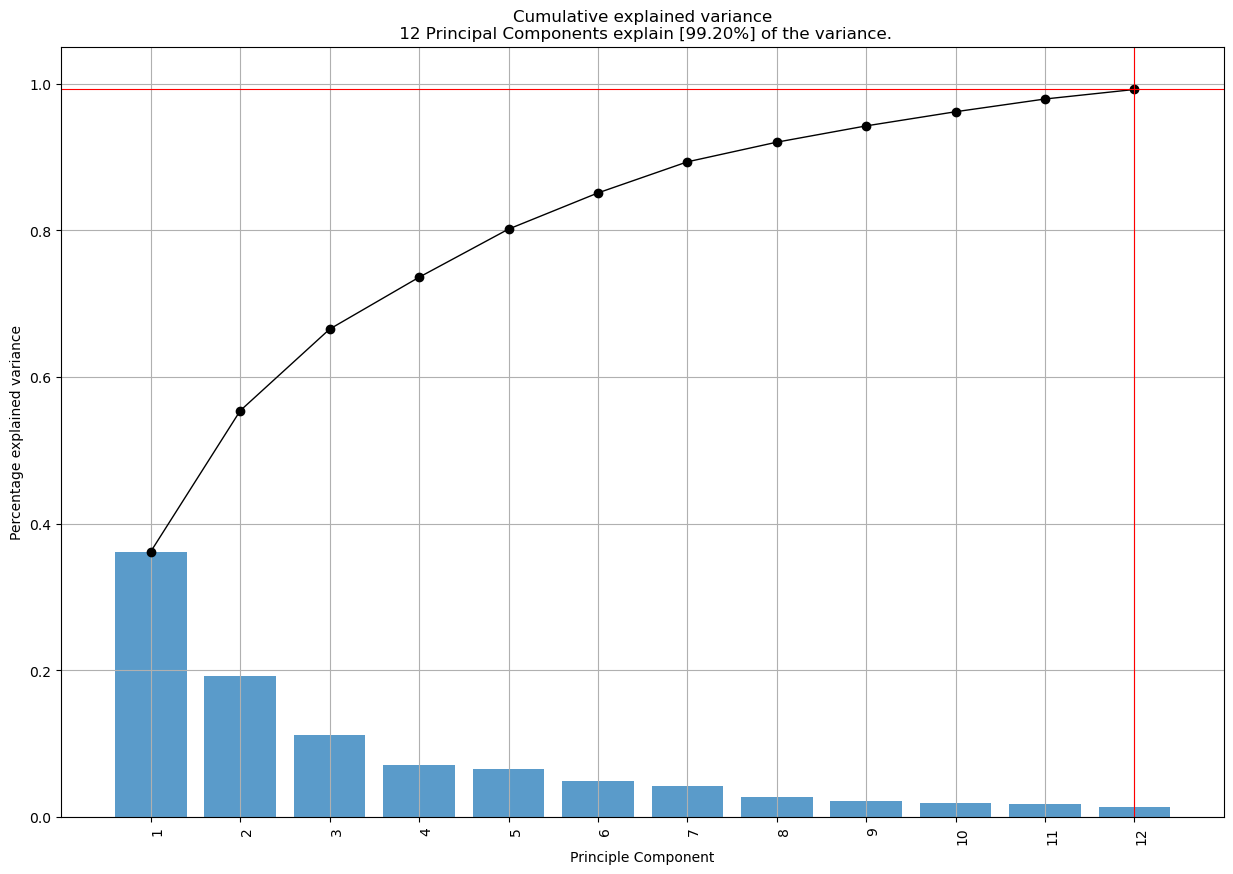

(<Figure size 1500x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'Cumulative explained variance\n 12 Principal Components explain [99.20%] of the variance.'}, xlabel='Principle Component', ylabel='Percentage explained variance'>)

<Figure size 640x480 with 0 Axes>

In [9]:
# Scree plot with explained variance
print("\033[1m" + "Fig. 1: Scree Plot" + "\033[0m")
model.plot()

We can now see the loadings in the code below. The loadings as discussed in the previous sections assist us in seeing how the features contribute to the PCs and how classes are divided.

In [10]:
# Top performing features
model.results["topfeat"]

,PC,feature,loading,type
0,PC1,flavanoids,0.422934,best
1,PC2,color_intensity,-0.529996,best
2,PC3,ash,0.626224,best
3,PC4,malic_acid,0.536890,best
4,PC5,magnesium,0.727049,best
5,PC6,malic_acid,-0.536814,best
6,PC7,nonflavanoid_phenols,0.595447,best
7,PC8,hue,-0.436624,best
8,PC9,proline,-0.575786,best
9,PC10,od280/od315_of_diluted_wines,0.523706,best


We can now visualize the scatter plot of the scores as shown below.

Fig. 2: Scatter plot of the Scores


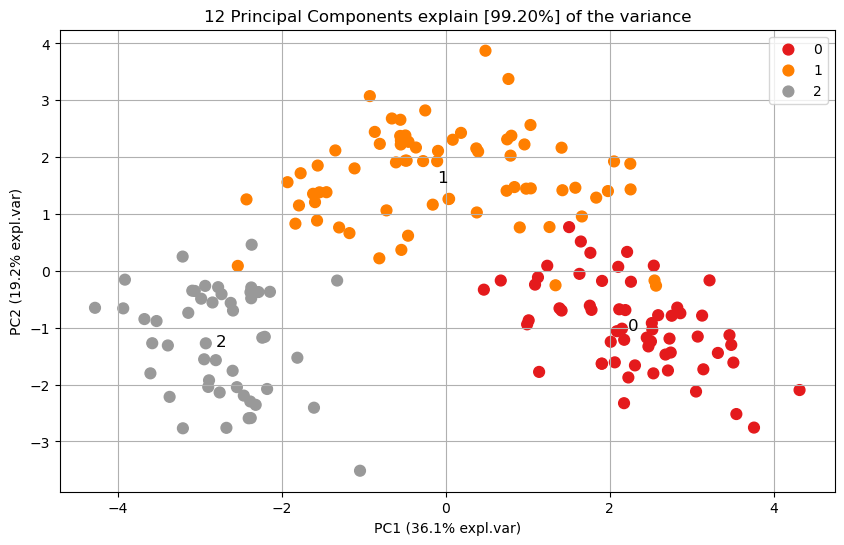

In [11]:
# Make plots

# Scatter plot
print("\033[1m" + "Fig. 2: Scatter plot of the Scores" + "\033[0m")
fig, ax = model.scatter(figsize=(10, 6))

From the scatter plot, we draw the biplot and note that the first 2 PCs can be sufficiently used to separate the first 3 classes.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

Fig. 3: Biplot
[pca] >Plot PC1 vs PC2 with loadings.


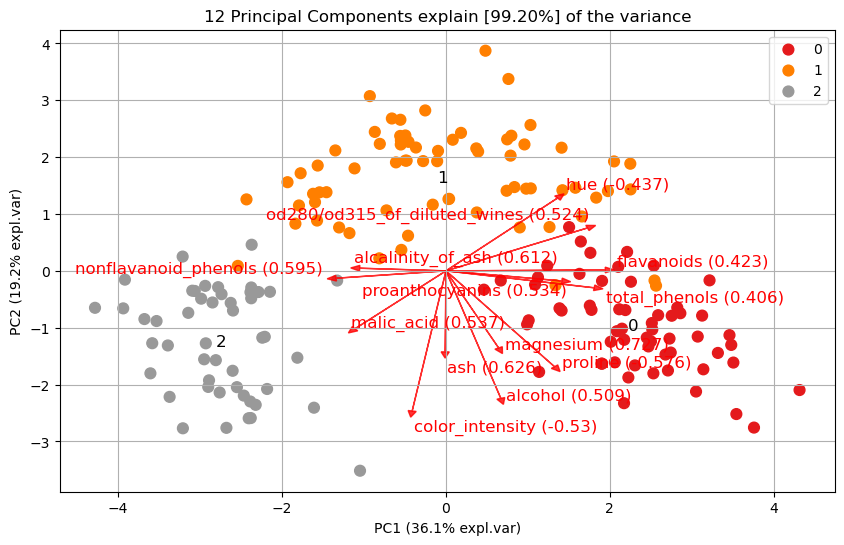

In [12]:
# Biplot
print("\033[1m" + "Fig. 3: Biplot" + "\033[0m")
fig, ax = model.biplot(figsize=(10, 6))

For a clear picture of the biplot without the scores, see below. Note that the lesser the angle between two features indicates that they contribute heavily to a principal component.

Fig. 3: Biplot without the scores
[pca] >Plot PC1 vs PC2 with loadings.


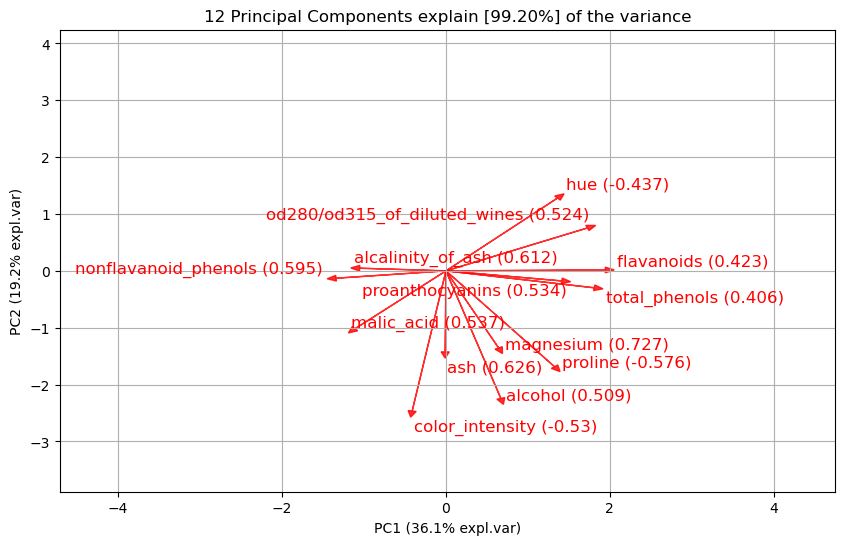

In [13]:
print("\033[1m" + "Fig. 3: Biplot without the scores" + "\033[0m")
fig, ax = model.biplot(cmap=None, label=False, legend=False, figsize=(10, 6))

## **3. Conclusion**

In this lesson, we introduced the concept of Principal Component Analysis, and in the next lesson, we will apply this knowledge to yield data.

**References**

- Abdi, Hervé, and Lynne J. Williams. "Principal Component Analysis." *Wiley Interdisciplinary Reviews: Computational Statistics*, vol. 2. no. 4, 2010, pp. 433-459.

- Ringnér, Markus. "What is Principal Component Analysis?" *Nature Biotechnology*, vol. 26, no. 3, 2008, pp. 303-304.

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
